In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from package.RankAMIP.logistic import run_logistic_regression
from package.RankAMIP.data_script import make_BT_design_matrix
from package.RankAMIP.logistic import LogisticAMIP
from package.RankAMIP.logistic import find_closest_matchups
from package.RankAMIP.logistic import isRankingRobust
from package.RankAMIP.data_script import *

### Load Data

In [2]:
# Import datasets from
# lmarena-ai/VisionArena-Battle
# https://huggingface.co/datasets/lmsys
from datasets import load_dataset
ds = load_dataset("lmarena-ai/webdev-arena-preference-10k")

/Users/JennyH/Library/Python/3.8/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# inspect the available splits
print(ds)  
# grab the test split
test = ds["test"]

DatasetDict({
    test: Dataset({
        features: ['model_a', 'model_b', 'conversation_a', 'conversation_b', 'winner', 'tstamp', 'anony', 'question_id'],
        num_rows: 10501
    })
})


In [4]:
df = test.to_pandas()
df.shape

(10501, 8)

In [5]:
df.head()

,model_a,model_b,conversation_a,conversation_b,winner,tstamp,anony,question_id
0,claude-3-5-sonnet-20241022,gemini-2.0-flash-thinking-exp-1219,"[{'content': [{'text': 'Machine,\nPls make web...","[{'content': [{'text': 'Machine,\nPls make web...",model_a,1.734980e+09,True,38fa1506bce8828d1996156a0a422bee
1,qwen-2.5-coder-32b-instruct,claude-3-5-sonnet-20241022,[{'content': [{'text': 'portfolio page for a f...,[{'content': [{'text': 'portfolio page for a f...,model_b,1.734879e+09,True,6d09f8ab32c62f355eb30a45192e485b
2,gemini-1.5-pro-002,qwen-2.5-coder-32b-instruct,"[{'content': [{'text': 'Snake Game', 'type': '...","[{'content': [{'text': 'Snake Game', 'type': '...",tie,1.734376e+09,True,d3c79f8667add0d2d1e33eba25dd6cec
3,gpt-4o-2024-11-20,claude-3-5-sonnet-20241022,[{'content': [{'text': 'Generate me a UI for d...,[{'content': [{'text': 'Generate me a UI for d...,model_b,1.734081e+09,True,9f688abafa4b68a72d63a46985854576
4,gemini-2.0-flash-thinking-exp-1219,claude-3-5-sonnet-20241022,"[{'content': [{'text': ""Build me Elon Musk's T...","[{'content': [{'text': ""Build me Elon Musk's T...",model_b,1.735158e+09,True,29fd8cb9774c3a6fa74af5d38e597123


In [6]:
# create a column winner_model_a, which is 1 if model_a is preferred, 0 if model_b is preferred
df['winner_model_a'] = df['winner'].apply(lambda x: 1 if x == 'model_a' else 0)
# create a column called winner_tie that is 1 if the winner is 'tie', else 0
df['winner_tie'] = df['winner'].apply(lambda x: 1 if x == 'tie' else 0)
df.head()

,model_a,model_b,conversation_a,conversation_b,winner,tstamp,anony,question_id,winner_model_a,winner_tie
0,claude-3-5-sonnet-20241022,gemini-2.0-flash-thinking-exp-1219,"[{'content': [{'text': 'Machine,\nPls make web...","[{'content': [{'text': 'Machine,\nPls make web...",model_a,1.734980e+09,True,38fa1506bce8828d1996156a0a422bee,1,0
1,qwen-2.5-coder-32b-instruct,claude-3-5-sonnet-20241022,[{'content': [{'text': 'portfolio page for a f...,[{'content': [{'text': 'portfolio page for a f...,model_b,1.734879e+09,True,6d09f8ab32c62f355eb30a45192e485b,0,0
2,gemini-1.5-pro-002,qwen-2.5-coder-32b-instruct,"[{'content': [{'text': 'Snake Game', 'type': '...","[{'content': [{'text': 'Snake Game', 'type': '...",tie,1.734376e+09,True,d3c79f8667add0d2d1e33eba25dd6cec,0,1
3,gpt-4o-2024-11-20,claude-3-5-sonnet-20241022,[{'content': [{'text': 'Generate me a UI for d...,[{'content': [{'text': 'Generate me a UI for d...,model_b,1.734081e+09,True,9f688abafa4b68a72d63a46985854576,0,0
4,gemini-2.0-flash-thinking-exp-1219,claude-3-5-sonnet-20241022,"[{'content': [{'text': ""Build me Elon Musk's T...","[{'content': [{'text': ""Build me Elon Musk's T...",model_b,1.735158e+09,True,29fd8cb9774c3a6fa74af5d38e597123,0,0


In [7]:
ties = df[df['winner_tie'] == 1]
print(f"Number of ties: {len(ties)}")
# proportion of ties.
print(f"Proportion of ties: {len(ties) / len(df):.2%}")
# note, the proportion of ties is 9.17% for the LLM-as-judge data and 23.25% for the human-as-judge data.

Number of ties: 766
Proportion of ties: 7.29%


In [8]:
rawBT = df[['model_a', 'model_b', 'winner_model_a', 'winner_tie']]
rawBT.head()
rawBT.shape
# rawBT_noTies.head() # (2575, 3)
# rawBT_noTies.shape

(10501, 4)

In [9]:
# how to get the unique names in both columns
model_a_names = df['model_a'].unique()
model_b_names = df['model_b'].unique()
# combine the two arrays and get the unique names
model_names = np.unique(np.concatenate((model_a_names, model_b_names)))
# print the number of unique model names
print(f"Number of unique model names: {len(model_names)}")

Number of unique model names: 13


In [10]:
for model in model_names:
    filtered = df[
        (df['model_a'] == model) | 
        (df['model_b'] == model)
    ]
    print(f"{model}: {filtered.shape[0]}")

claude-3-5-haiku-20241022: 1119
claude-3-5-sonnet-20241022: 2637
deepseek-v3: 969
gemini-1.5-pro-002: 2265
gemini-2.0-flash-exp: 2319
gemini-2.0-flash-thinking-exp-1219: 1677
gemini-exp-1206: 2437
gpt-4o-2024-11-20: 2523
llama-v3.1-405b-instruct: 235
llama-v3.3-70b-instruct: 25
o1-2024-12-17: 790
o1-mini-2024-09-12: 1746
qwen-2.5-coder-32b-instruct: 2260


In [11]:
# make the BT design matrix.
X, y, player_to_id = make_BT_design_matrix(rawBT, weight_tie = True)
X.shape, y.shape

((21002, 12), (21002,))

## Uniform Data-dropping

In [50]:
# compute BT scores.
model_full = run_logistic_regression(X, y)

# prepend model 0, the reference model, which has score 0.
bt_scores = np.insert(model_full.coef_[0], 0, 0)

# combine bt_scores with player names
id_to_player = {v: k for k, v in player_to_id.items()}
bt_scores_with_names = {id_to_player[i]: score for i, score in enumerate(bt_scores)}

# Determine the original top model
top_model_original = max(bt_scores_with_names.items(), key=lambda x: x[1])[0]
print("original top 5 models: ", dict(sorted(bt_scores_with_names.items(), key=lambda x: x[1], reverse=True)[:5]))

num_trials = 100
num_agree = 0

for trial in range(num_trials):
    indices = np.random.choice(X.shape[0], size=int(X.shape[0]*0.01), replace=False)
    X_dropped = np.delete(X, indices, axis=0)
    y_dropped = np.delete(y, indices, axis=0)

    model_dropped = run_logistic_regression(X_dropped, y_dropped)
    bt_scores_dropped = np.insert(model_dropped.coef_[0], 0, 0)
    bt_scores_with_names_dropped = {id_to_player[i]: score for i, score in enumerate(bt_scores_dropped)}
    top_model_dropped = max(bt_scores_with_names_dropped.items(), key=lambda x: x[1])[0]
    if top_model_dropped == top_model_original:
        num_agree += 1

    # Optional: Show some progress every 10 iterations
    if (trial+1) % 10 == 0:
        print(f"Completed {trial+1} trials...")

print(f"Fraction of times top-ranked model stays the same after dropping 1% of the data: {num_agree/num_trials:.2f}")

original top 5 models:  {'claude-3-5-sonnet-20241022': 0.0, 'claude-3-5-haiku-20241022': -0.7166046653486599, 'o1-mini-2024-09-12': -1.1012096994479388, 'o1-2024-12-17': -1.1277159841056628, 'gemini-2.0-flash-thinking-exp-1219': -1.3900772834989787}
Completed 10 trials...
Completed 20 trials...
Completed 30 trials...
Completed 40 trials...
Completed 50 trials...
Completed 60 trials...
Completed 70 trials...
Completed 80 trials...
Completed 90 trials...
Completed 100 trials...
Fraction of times top-ranked model stays the same after dropping 1% of the data: 1.00


#### Run Top-k Robustness Check.

In [18]:
import importlib
from package.RankAMIP import logistic, plot_util

importlib.reload(logistic)
from package.RankAMIP.logistic import LogisticAMIP, isRankingRobust

In [ ]:
ks = [1]
results = {}
for k in ks:
    alphaN = 1
    chatbotA = -1
    while chatbotA == -1:
        chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatNewBetaDiffAMIP, chatIndices = isRankingRobust(k, alphaN, X, y,  weighted = True)
        results[(k, alphaN)] = (chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatNewBetaDiffAMIP, chatIndices)
        alphaN += 1

In [17]:
# find the (k, alpha N) pairs that are non-robust.
results_nonrobust = {k: v for k, v in results.items() if v[0] != -1}
results_nonrobust

{(1, 18): (11,
  None,
  -2.6720424681191846,
  0.18372213346714347,
  -1.7345673736393405,
  array([ 7164,  7539,  9112,  7711,  2089,  1815,  2414,  8753,  4883,
          6446,  6542,  2889,  9272,  3553,  1512,  6992,  5933, 10387]))}

In [ ]:
# save results as a .pkl file.
# import pickle
# with open('results/webdevNonrobustWtd.pkl', 'wb') as f:
#     pickle.dump(results_nonrobust, f)

### Robustness of Bootstrap Confidence Interval Rankings

In [ ]:
import importlib
import compute_CIs
importlib.reload(compute_CIs)

<module 'compute_CIs' from '/Users/JennyH/Desktop/IsRankingRobust/compute_CIs.py'>

In [22]:
BOOTSTRAP_ROUNDS = 100
### Obtain Bootstrap Confidence Intervals.
np.random.seed(42)
bootstrap_elo_lu = compute_CIs.get_bootstrap_result(df, compute_CIs.compute_mle_elo, BOOTSTRAP_ROUNDS)

bootstrap: 100%|██████████| 100/100 [00:02<00:00, 35.83it/s]


In [27]:
bootstrap_elo_lu.describe()
# show the 95% confidence interval for each model
ci_lower = bootstrap_elo_lu.quantile(0.025)
ci_upper = bootstrap_elo_lu.quantile(0.975)
ci_med = bootstrap_elo_lu.median()
ci_df = pd.DataFrame({
    "2.5%": ci_lower,
    "Median": ci_med,
    "97.5%": ci_upper
})
ci_df

,2.5%,Median,97.5%
claude-3-5-sonnet-20241022,1235.324710,1255.026066,1271.102837
claude-3-5-haiku-20241022,1118.387984,1140.670398,1162.609642
o1-mini-2024-09-12,1060.234350,1072.444206,1091.584733
o1-2024-12-17,1045.380910,1071.689449,1090.309586
gemini-2.0-flash-thinking-exp-1219,1018.020156,1034.769126,1051.479520
gemini-exp-1206,1001.442433,1015.950300,1033.789166
gemini-2.0-flash-exp,957.255994,972.955238,988.052891
llama-v3.3-70b-instruct,797.789701,965.193105,1000.000000
deepseek-v3,937.978406,959.750003,984.470843
gpt-4o-2024-11-20,942.576585,957.413363,973.199799


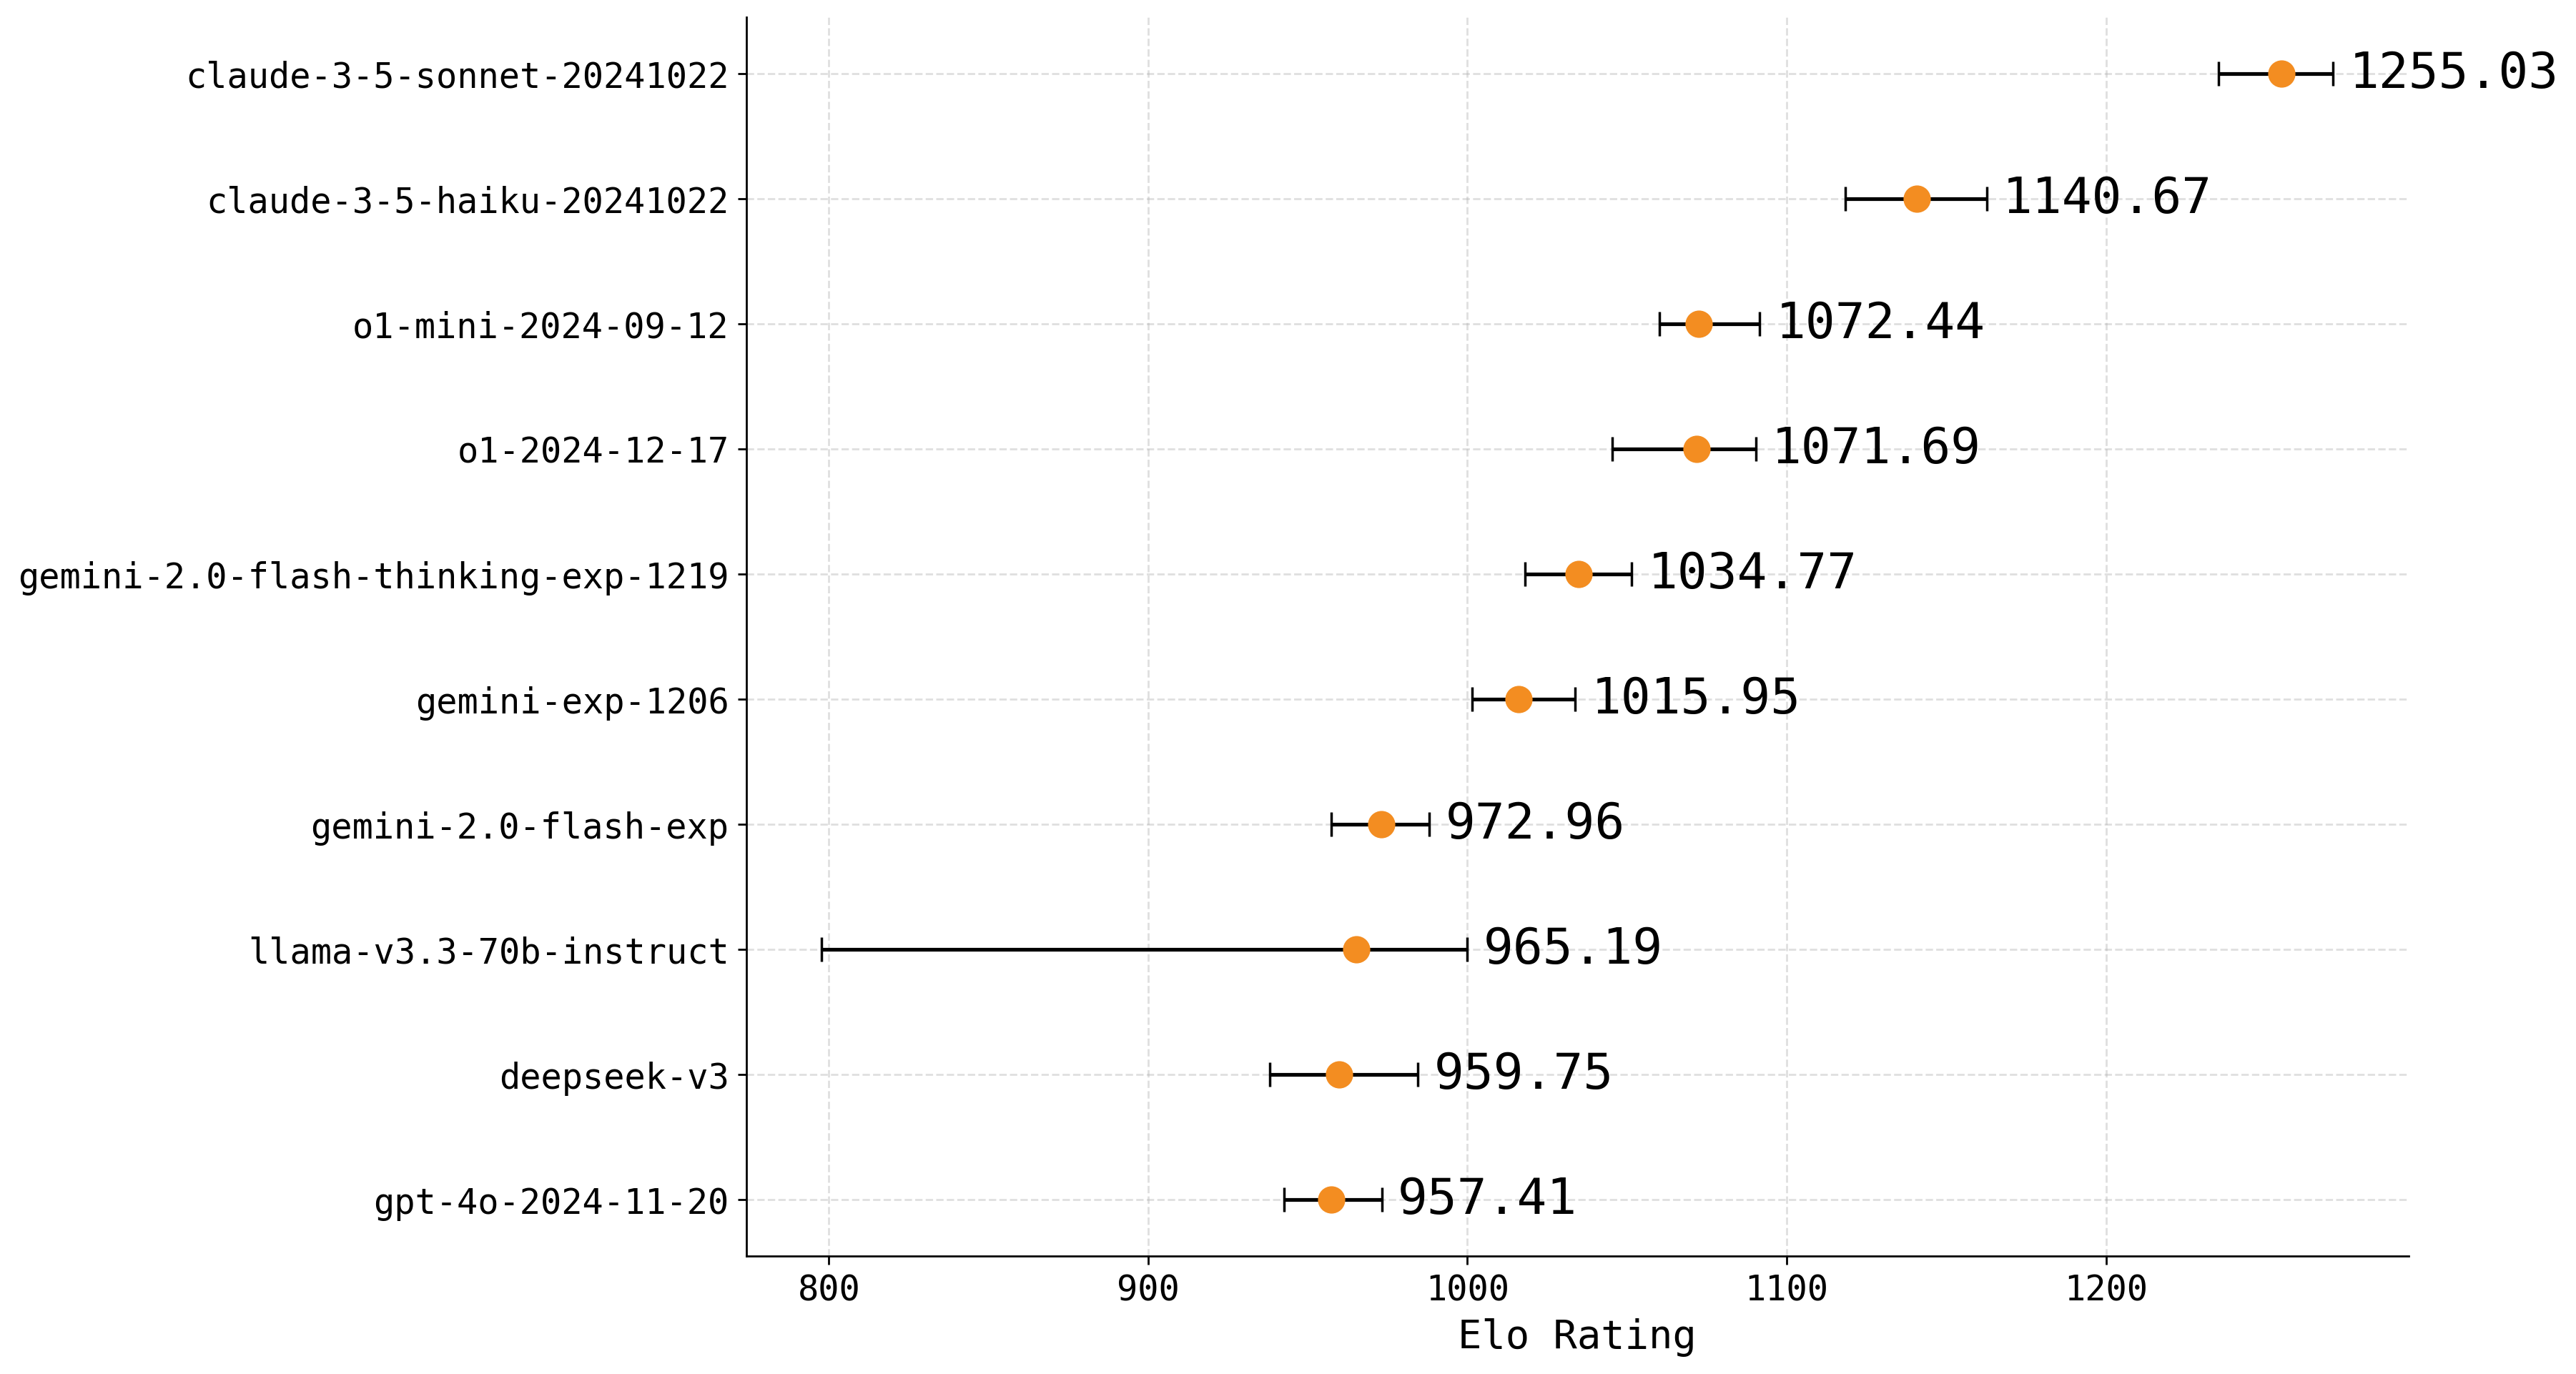

In [ ]:
# plot the top 10 models.
compute_CIs.plot_elo_confidence_intervals(ci_df.head(10))

Load in the most influential sets.

In [ ]:
import pickle
with open('results/webdevNonrobustWtd.pkl', 'rb') as f:
    results_nonrobust_loaded = pickle.load(f)

In [30]:
results_nonrobust_loaded

{(1, 18): (11,
  None,
  -2.6720424681191832,
  0.1837221334672124,
  array([ 7164,  7539,  9112,  7711,  2089,  1815,  2414,  6542,  6446,
          4883,  8753,  2889,  9272,  3553,  1512,  5933,  6992, 10387])),
 (5, 13): (3,
  11,
  1.2819651846202045,
  -0.12369178206385278,
  array([7164, 7539, 9112, 7711, 1815, 2089, 2414, 6542, 6446, 4883, 8753,
         2889, 9272]))}

#### Identify the pool of influential points for auditing Top-1 Robustness

In [167]:
import math
k = 3
alphaN = math.floor(0.02 * len(df))
print(alphaN)
chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatNewBetaDiffAMIP, top1_mis_indices = isRankingRobust(k, alphaN, X, y,  weighted = True)

210


bootstrap: 100%|██████████| 100/100 [00:03<00:00, 31.11it/s]


fraction of preferences dropped: 0.01523664412913056


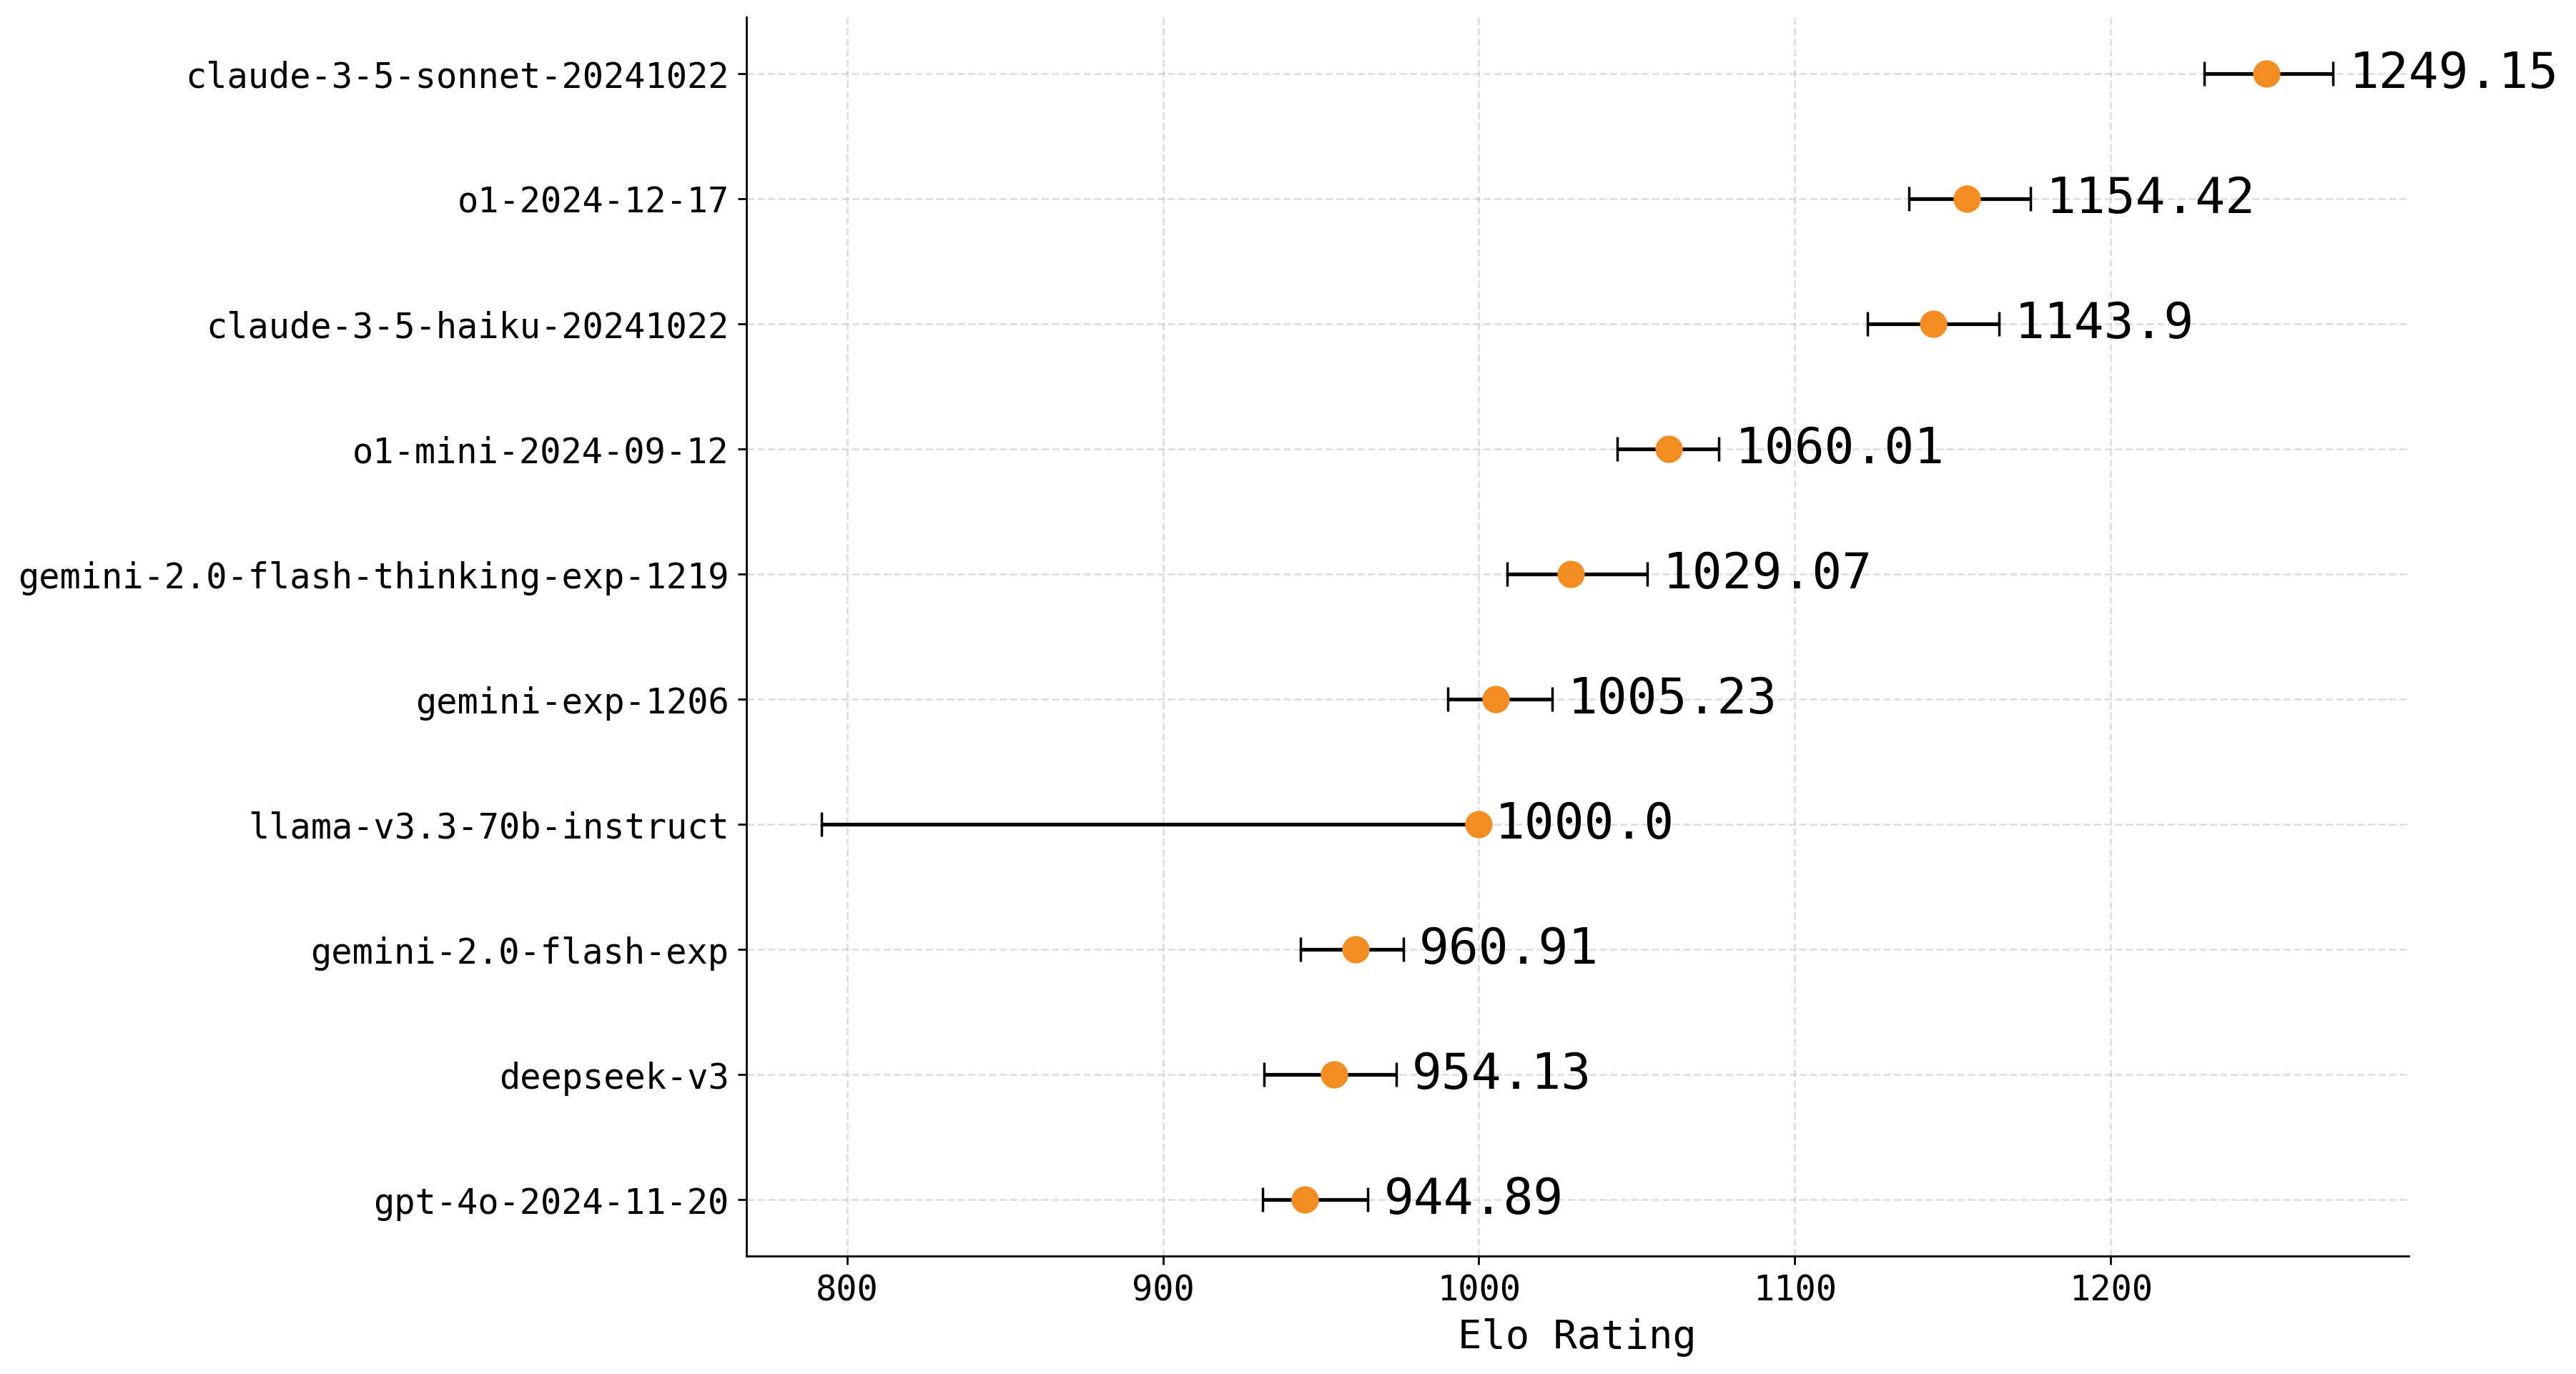

In [169]:
# remove top_1_mis from df
num_dropped = 160 # 160
df_dropped = df.drop(top1_mis_indices[:num_dropped]).reset_index(drop=True)

len(df), len(df_dropped)

BOOTSTRAP_ROUNDS = 100
bootstrap_top1_mis_dropped = compute_CIs.get_bootstrap_result(df_dropped, compute_CIs.compute_mle_elo, BOOTSTRAP_ROUNDS)

bootstrap_top1_mis_dropped.describe()
# show the 95% confidence interval for each model
ci_lower = bootstrap_top1_mis_dropped.quantile(0.025)
ci_upper = bootstrap_top1_mis_dropped.quantile(0.975)
ci_med = bootstrap_top1_mis_dropped.median()
ci_df_dropped = pd.DataFrame({
    "2.5%": ci_lower,
    "Median": ci_med,
    "97.5%": ci_upper,
})
ci_df_dropped

print(f'fraction of preferences dropped: {num_dropped / len(df)}')
compute_CIs.plot_elo_confidence_intervals(ci_df_dropped.head(10), title=f"Top 10 Elo Ratings Upon Removing {num_dropped} out of {len(df)} of Preferences")


In [22]:
for model in model_names:
    filtered = df[
        (df['model_a'] == model) | 
        (df['model_b'] == model)
    ]
    print(f"{model}: {filtered.shape[0]}")

claude-3-5-haiku-20241022: 1119
claude-3-5-sonnet-20241022: 2637
deepseek-v3: 969
gemini-1.5-pro-002: 2265
gemini-2.0-flash-exp: 2319
gemini-2.0-flash-thinking-exp-1219: 1677
gemini-exp-1206: 2437
gpt-4o-2024-11-20: 2523
llama-v3.1-405b-instruct: 235
llama-v3.3-70b-instruct: 25
o1-2024-12-17: 790
o1-mini-2024-09-12: 1746
qwen-2.5-coder-32b-instruct: 2260


In [18]:
from package.RankAMIP.plot_util import *
rankings = return_rankings_list(X, y, results, 1, 18, player_to_id)

In [19]:
# plot the rankings on the original arena
filename_to_save = 'fig/top10_webdev.png'
plot_title = 'Model Rankings in Webdev Arena'
plot_bt_scores(X, y, rankings, alphaN, 10, plot_title, filename_to_save)

In [21]:
results_nonrobust

{(1, 18): (11,
  None,
  -2.6720424681191832,
  0.1837221334672124,
  array([ 7164,  7539,  9112,  7711,  2089,  1815,  2414,  6542,  6446,
          4883,  8753,  2889,  9272,  3553,  1512,  5933,  6992, 10387])),
 (5, 13): (3,
  11,
  1.2819651846202045,
  -0.12369178206385278,
  array([7164, 7539, 9112, 7711, 1815, 2089, 2414, 6542, 6446, 4883, 8753,
         2889, 9272]))}

In [23]:
# find the two models that changed ranking.
## Count number of games between the first- and second-place models played in total.
is_haiku_sonnet = (
    (df['model_a'].str.contains('claude-3-5-sonnet-20241022') & df['model_b'].str.contains('claude-3-5-haiku-20241022')) |
    (df['model_a'].str.contains('claude-3-5-haiku-20241022') & df['model_b'].str.contains('claude-3-5-sonnet-20241022'))
)

num_haiku_sonnet = df[is_haiku_sonnet].shape[0]
print("Number of games between claude haiku and claude sonnet: ", num_haiku_sonnet)

Number of games between claude haiku and claude sonnet:  95


In [24]:
# model pairs
df['model_pair'] = df.apply(lambda row: tuple(sorted([row['model_a'], row['model_b']])), axis=1)
df['model_pair']

# Compute average games per model pair across the arena.
pair_counts = df['model_pair'].value_counts()
average_games_per_pair = pair_counts.mean()
print("Average number of games per model pair:", average_games_per_pair)

Average number of games per model pair: 145.84722222222223


In [30]:
df['winner_model_b'] = ((df['winner_model_a'] == 0) & (df['winner_tie'] == 0)).astype(int)
df.head()

,model_a,model_b,conversation_a,conversation_b,winner,tstamp,anony,question_id,winner_model_a,winner_tie,model_pair,winner_model_b
0,claude-3-5-sonnet-20241022,gemini-2.0-flash-thinking-exp-1219,"[{'content': [{'text': 'Machine,\nPls make web...","[{'content': [{'text': 'Machine,\nPls make web...",model_a,1.734980e+09,True,38fa1506bce8828d1996156a0a422bee,1,0,"(claude-3-5-sonnet-20241022, gemini-2.0-flash-...",0
1,qwen-2.5-coder-32b-instruct,claude-3-5-sonnet-20241022,[{'content': [{'text': 'portfolio page for a f...,[{'content': [{'text': 'portfolio page for a f...,model_b,1.734879e+09,True,6d09f8ab32c62f355eb30a45192e485b,0,0,"(claude-3-5-sonnet-20241022, qwen-2.5-coder-32...",1
2,gemini-1.5-pro-002,qwen-2.5-coder-32b-instruct,"[{'content': [{'text': 'Snake Game', 'type': '...","[{'content': [{'text': 'Snake Game', 'type': '...",tie,1.734376e+09,True,d3c79f8667add0d2d1e33eba25dd6cec,0,1,"(gemini-1.5-pro-002, qwen-2.5-coder-32b-instruct)",0
3,gpt-4o-2024-11-20,claude-3-5-sonnet-20241022,[{'content': [{'text': 'Generate me a UI for d...,[{'content': [{'text': 'Generate me a UI for d...,model_b,1.734081e+09,True,9f688abafa4b68a72d63a46985854576,0,0,"(claude-3-5-sonnet-20241022, gpt-4o-2024-11-20)",1
4,gemini-2.0-flash-thinking-exp-1219,claude-3-5-sonnet-20241022,"[{'content': [{'text': ""Build me Elon Musk's T...","[{'content': [{'text': ""Build me Elon Musk's T...",model_b,1.735158e+09,True,29fd8cb9774c3a6fa74af5d38e597123,0,0,"(claude-3-5-sonnet-20241022, gemini-2.0-flash-...",1


In [33]:
# Find the win margin between 'claude-3-5-haiku-20241022' and 'claude-3-5-sonnet-20241022'
# that is, find all games that are between the two models.
dfFlippedRanking = df[is_haiku_sonnet]
## Count number of games between that 'claude-3-5-haiku-20241022' won.
haiku_wins = (
    (dfFlippedRanking['model_a'].str.contains('claude-3-5-haiku-20241022') & dfFlippedRanking['winner_model_a'] == 1) |
    (dfFlippedRanking['model_b'].str.contains('claude-3-5-haiku-20241022') & dfFlippedRanking['winner_model_b'] == 1)
)
num_haiku_wins = dfFlippedRanking[haiku_wins].shape[0]
 # 0.5373134328358209

sonnet_wins = (
    (dfFlippedRanking['model_a'].str.contains('claude-3-5-sonnet-20241022') & dfFlippedRanking['winner_model_a'] == 1) |
    (dfFlippedRanking['model_b'].str.contains('claude-3-5-sonnet-20241022') & dfFlippedRanking['winner_model_b'] == 1)
)

num_haiku_wins = dfFlippedRanking[haiku_wins].shape[0]
num_sonnet_wins = dfFlippedRanking[sonnet_wins].shape[0]

print("Proportion of games that claude sonnet won: ", num_sonnet_wins / (num_haiku_wins + num_sonnet_wins))


Proportion of games that claude sonnet won:  0.6976744186046512


In [32]:
num_haiku_wins, num_sonnet_wins

(26, 60)